In [1]:
from skimage._shared.coord import ensure_spacing
from scids.functional import dist
import numpy as np
from profileit.function import FunctionProfiler
import scipy as sp

In [ ]:
for i in range(1000):
    a=np.random.rand(1000, 3) * 10
    median_dist = np.median(sp.spatial.distance.pdist(a))
    r=np.linspace(1, median_dist/2, 1000)
    # r1=ensure_spacing(a, spacing=median_dist, p_norm=2)
    r2=a[dist.exclude_overlapping_spheres(a, r, batch_threshold=np.inf)]
    r3=a[dist.exclude_overlapping_spheres(a, r, batch_threshold=0)]
    # assert np.array_equal(r1,r2)
    if not np.array_equal(r2,r3):
        print(r2 - r3)

In [2]:
def gen1(sizes):
    np.random.seed(42)
    for size in sizes:
        yield (np.random.rand(size, 3),), {"spacing":1.5, "p_norm":2}
def gen2(sizes):
    np.random.seed(42)
    for size in sizes:
        yield (np.random.rand(size, 3), 1.5/2), {"batch_threshold":np.inf}
def gen3(sizes):
    np.random.seed(42)
    for size in sizes:
        yield (np.random.rand(size, 3), 1.5/2), {"batch_threshold":0}
def gen4(sizes):
    np.random.seed(42)
    for size in sizes:
        yield (np.random.rand(size, 3), np.random.rand(size)), {"batch_threshold":np.inf}
def gen5(sizes):
    np.random.seed(42)
    for size in sizes:
        yield (np.random.rand(size, 3), np.random.rand(size)), {"batch_threshold":0}

profiler = FunctionProfiler(
    funcs=[ensure_spacing, dist.exclude_overlapping_spheres, dist.exclude_overlapping_spheres, dist.exclude_overlapping_spheres, dist.exclude_overlapping_spheres],
    arg_gens=[gen1, gen2, gen3, gen4, gen5],
    func_names=["skimage", "unbatched_1r", "batched_1r", "unbatched_nr", "batched_nr"]
)

In [3]:
profiler.profile([10, 100, 1000, 10_000, 100_000])

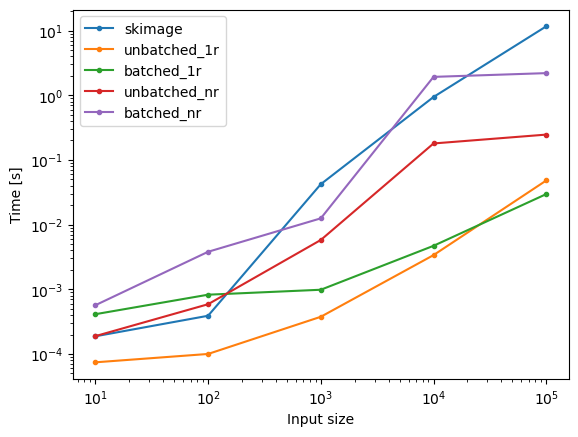

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Input size', ylabel='Time [s]'>)

In [4]:
profiler.plot()